In [6]:
import pandas as pd
import os
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
path_splits = "../demonstrative_applications/case_demo_01/splits/"
folder_embedding = "embedding_esm2_t6_8M_UR50D_mean_last_bs4_cuda_fp32"
algorithms = {"knn": "KNN", 
              "logistic_regression": "Logistic Regression", 
              "random_forest": "Random Forest", 
              "svm": "SVM"}

In [8]:
general_partitions = os.listdir(path_splits)
general_partitions

['cluster_aware_k50',
 'cluster_aware_k200',
 'cluster_aware_k400',
 'random',
 'cluster_aware_k100',
 'stratified',
 'cluster_aware_k500',
 'cluster_aware_k300']

In [9]:
df_performances = []

for partition in general_partitions:
    seeds = os.listdir(f"{path_splits}{partition}")
    for seed in seeds:
        for algorithm in algorithms:
            metrics_doc = f"{path_splits}{partition}/{seed}/models/{algorithm}/{folder_embedding}/metrics.json"

            with open(metrics_doc, 'r') as doc_metrics:
                metrics_values = json.load(doc_metrics)
            
            name_partition = ""

            k_partition = None

            if "cluster" in partition:
                name_partition = "Cluster aware"
                k_partition = partition.split("k")[-1]

            elif "random" in partition:
                name_partition = "Random"
            else:
                name_partition = "Stratified"

            row = {
                "Partition": name_partition,
                "folder" : partition,
                "k" : k_partition,
                "Seed" : seed,
                "Algorithm" : algorithms[algorithm],
                "AUPRC train" : metrics_values["train"]["auprc"],
                "AUPRC val" : metrics_values["val"]["auprc"],
                "AUPRC test" : metrics_values["test"]["auprc"]
            }
            df_performances.append(row)
        
df_performances = pd.DataFrame(df_performances)
df_performances

,Partition,folder,k,Seed,Algorithm,AUPRC train,AUPRC val,AUPRC test
0,Cluster aware,cluster_aware_k50,50,seed_7,KNN,1.000000,1.000000,0.756370
1,Cluster aware,cluster_aware_k50,50,seed_7,Logistic Regression,0.920810,0.651396,0.729778
2,Cluster aware,cluster_aware_k50,50,seed_7,Random Forest,1.000000,1.000000,0.741955
3,Cluster aware,cluster_aware_k50,50,seed_7,SVM,0.950659,0.736717,0.763416
4,Cluster aware,cluster_aware_k50,50,seed_1,KNN,1.000000,1.000000,0.819653
...,...,...,...,...,...,...,...,...
315,Cluster aware,cluster_aware_k300,300,seed_8,SVM,0.933370,0.895581,0.865277
316,Cluster aware,cluster_aware_k300,300,seed_2,KNN,1.000000,1.000000,0.736603
317,Cluster aware,cluster_aware_k300,300,seed_2,Logistic Regression,0.900158,0.911609,0.726648
318,Cluster aware,cluster_aware_k300,300,seed_2,Random Forest,1.000000,1.000000,0.746728


In [10]:
df_performances["Partition"].value_counts()

Partition
Cluster aware    240
Random            40
Stratified        40
Name: count, dtype: int64

- Ploting differences in performances between validation/testing by partition

In [11]:
df_performances.to_csv("tmp.csv", index=False)

In [12]:
df_performances_val = df_performances[["Partition", "Seed",	"Algorithm", "AUPRC val"]]
df_performances_val.columns = ["Partition", "Seed",	"Algorithm", "AUPRC"]
df_performances_val["Stage"] = "Validation"

df_performances_test = df_performances[["Partition", "Seed",	"Algorithm", "AUPRC test"]]
df_performances_test.columns = ["Partition", "Seed",	"Algorithm", "AUPRC"]
df_performances_test["Stage"] = "Testing"

df_to_plot = pd.concat([df_performances_val, df_performances_test], axis=0, ignore_index=True)

<Axes: xlabel='Algorithm', ylabel='AUPRC test'>

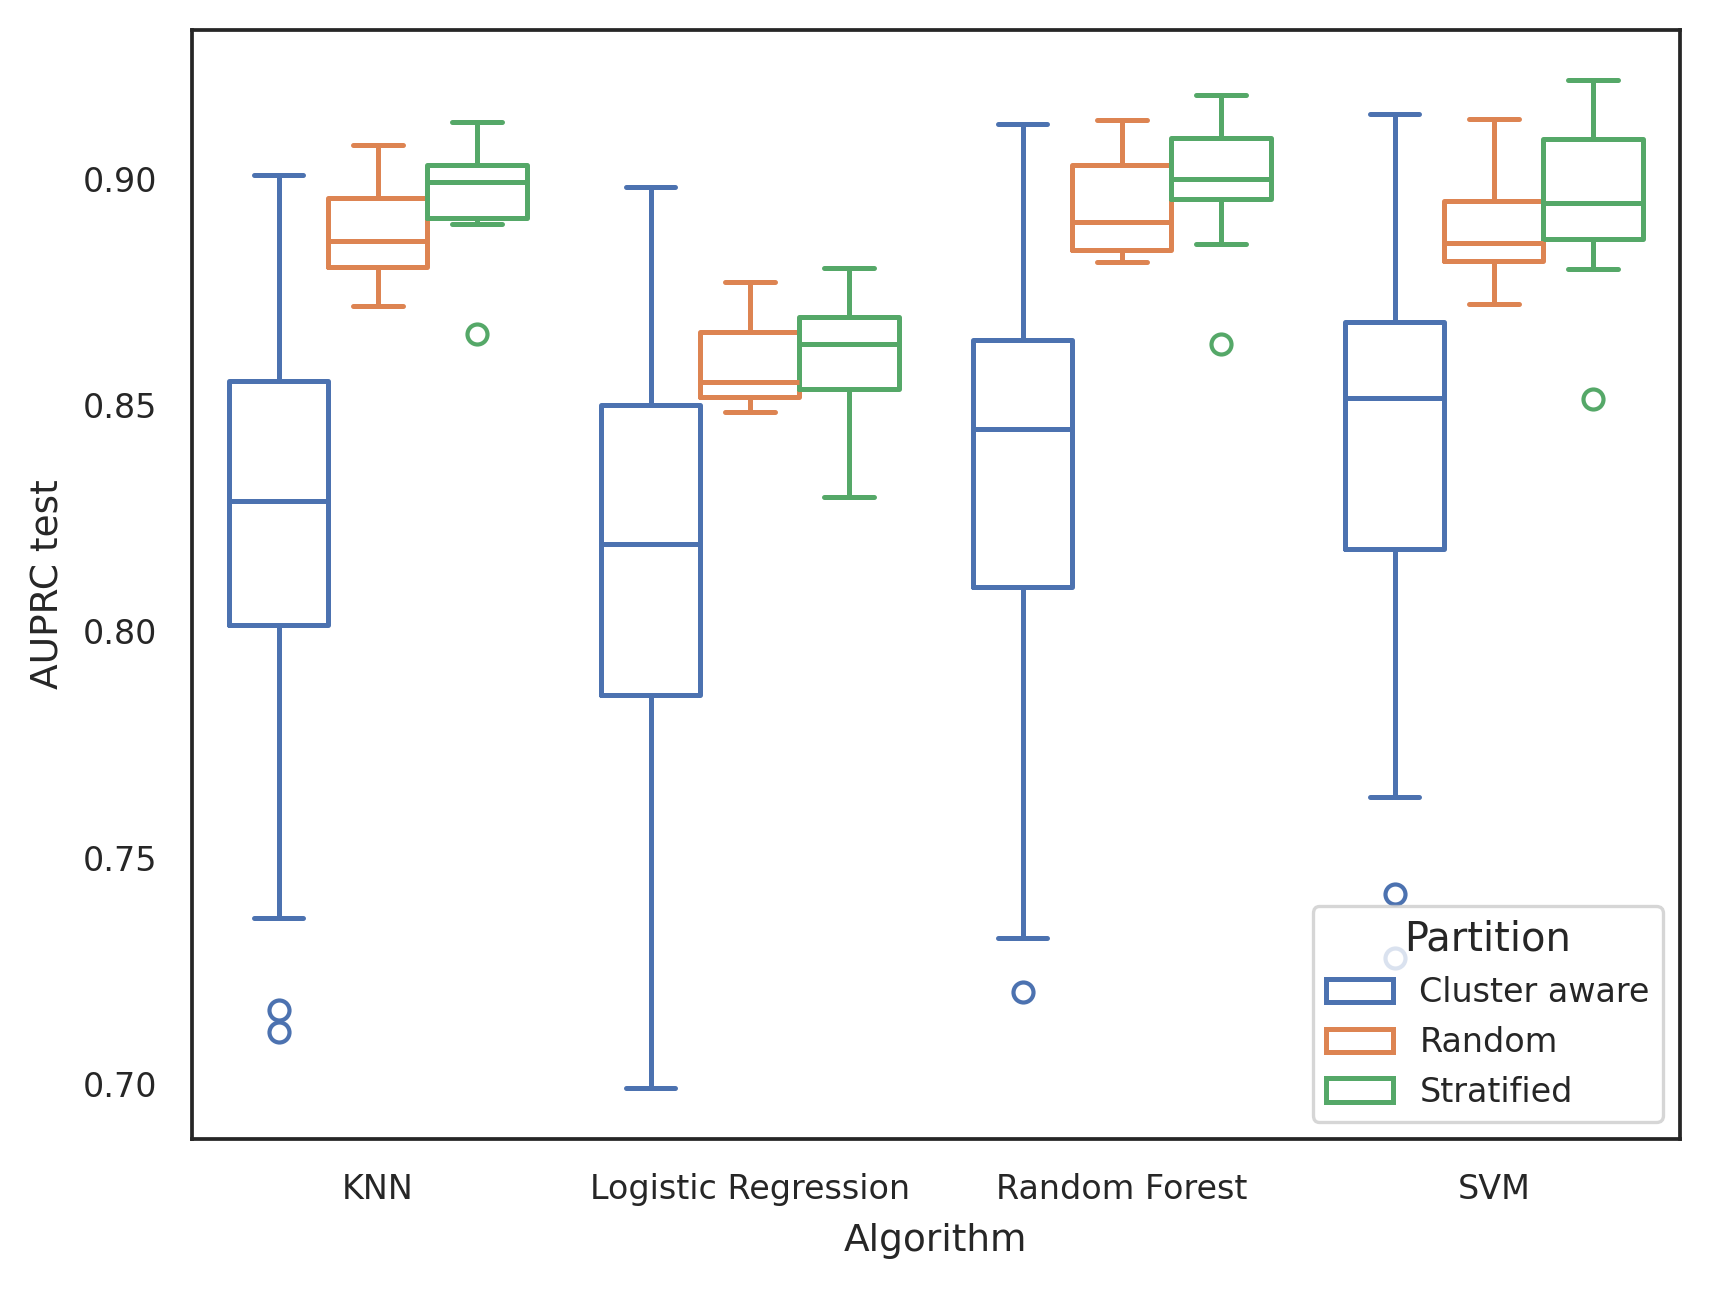

In [13]:
sns.boxplot(data=df_performances, y="AUPRC test", x="Algorithm", hue="Partition", fill=False)

<Axes: xlabel='Algorithm', ylabel='AUPRC'>

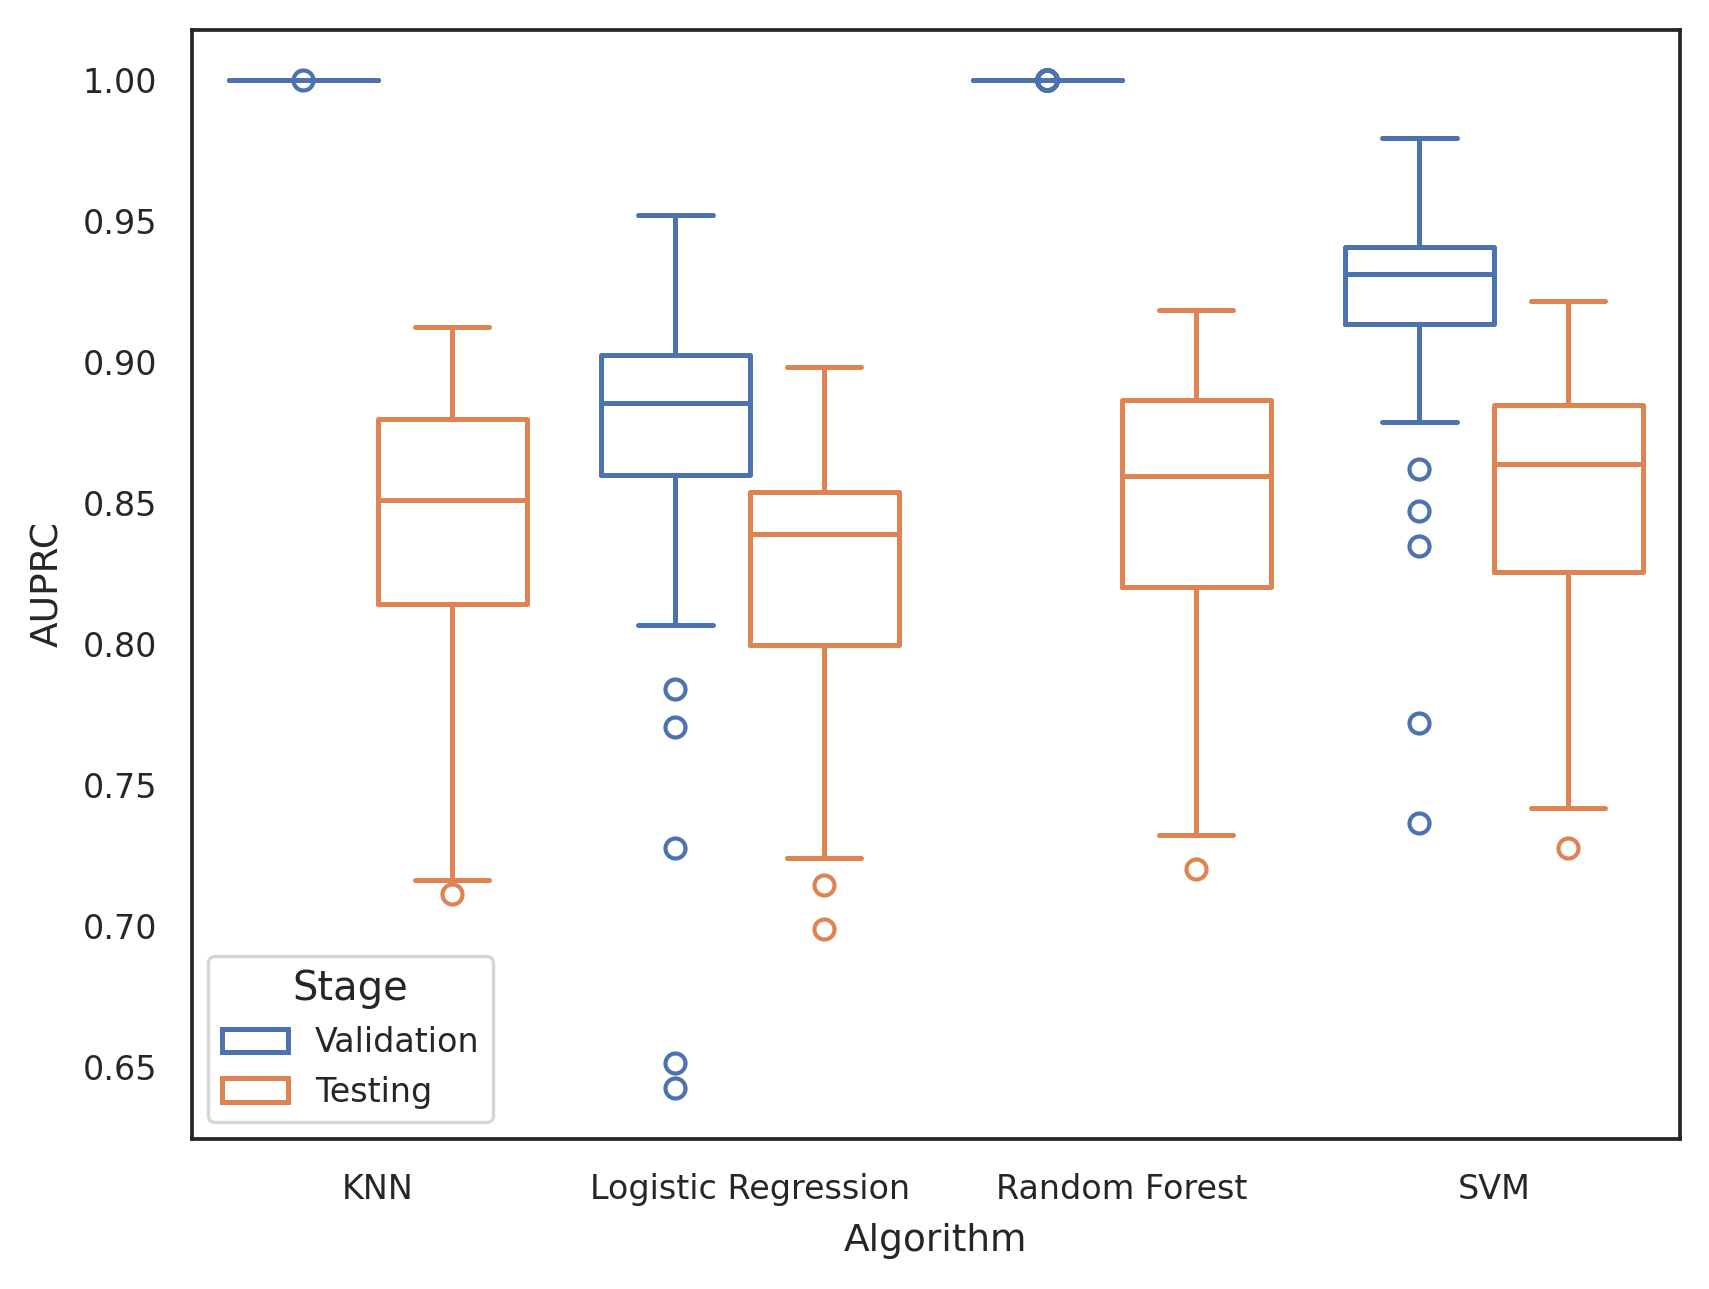

In [14]:
sns.boxplot(data=df_to_plot, y="AUPRC", x="Algorithm", hue="Stage", fill=False)

In [15]:
fragility = (
    df_performances
    .groupby(["Algorithm", "Partition"])["AUPRC test"]
    .agg(
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        median="median",
        n_seeds="count"
    )
    .reset_index()
)

fragility["IQR"] = fragility["q75"] - fragility["q25"]
fragility

,Algorithm,Partition,q25,q75,median,n_seeds,IQR
0,KNN,Cluster aware,0.801438,0.855339,0.828714,60,0.053902
1,KNN,Random,0.880539,0.895717,0.886301,10,0.015179
2,KNN,Stratified,0.891347,0.903061,0.899355,10,0.011714
3,Logistic Regression,Cluster aware,0.785950,0.850069,0.819340,60,0.064119
4,Logistic Regression,Random,0.851737,0.866033,0.855094,10,0.014296
5,Logistic Regression,Stratified,0.853462,0.869332,0.863393,10,0.015870
6,Random Forest,Cluster aware,0.809781,0.864251,0.844636,60,0.054469
7,Random Forest,Random,0.884321,0.902905,0.890393,10,0.018583
8,Random Forest,Stratified,0.895598,0.908958,0.899939,10,0.013361
9,SVM,Cluster aware,0.818088,0.868220,0.851488,60,0.050132


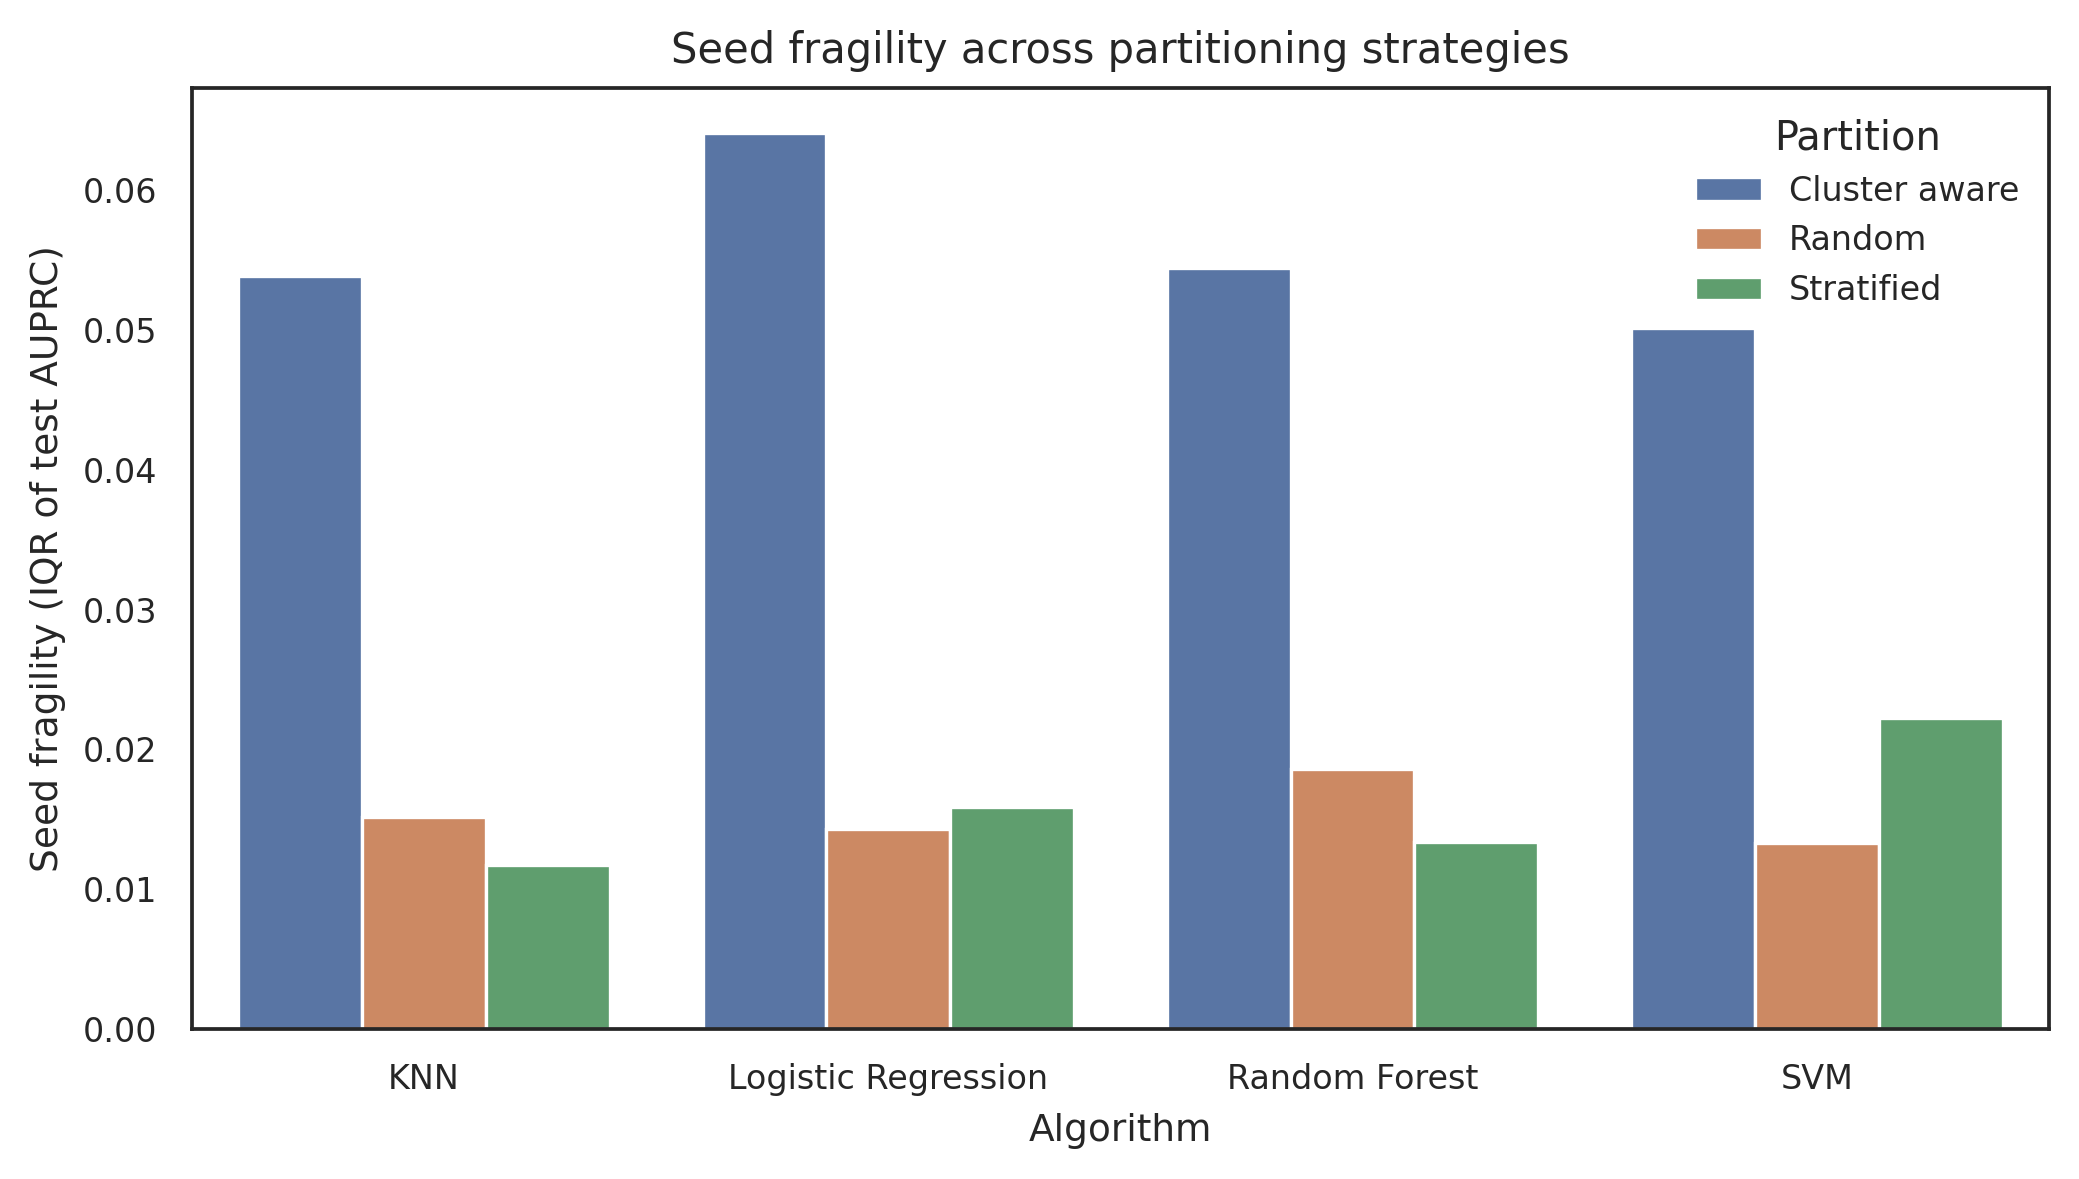

In [16]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=fragility,
    x="Algorithm",
    y="IQR",
    hue="Partition",
    errorbar=None
)

plt.ylabel("Seed fragility (IQR of test AUPRC)")
plt.xlabel("Algorithm")
plt.title("Seed fragility across partitioning strategies")
plt.legend(title="Partition", frameon=False)

plt.tight_layout()
plt.show()


In [17]:
fragility_ratio = (
    fragility
    .pivot(index="Algorithm", columns="Partition", values="IQR")
)

fragility_ratio["Cluster v/s Random"] = (
    fragility_ratio["Cluster aware"] / fragility_ratio["Random"]
)

fragility_ratio["Cluster v/s Stratified"] = (
    fragility_ratio["Cluster aware"] / fragility_ratio["Stratified"]
)

fragility_ratio["Random v/s Stratified"] = (
    fragility_ratio["Random"] / fragility_ratio["Stratified"]
)

fragility_ratio


Partition,Cluster aware,Random,Stratified,Cluster v/s Random,Cluster v/s Stratified,Random v/s Stratified
Algorithm,,,,,,
KNN,0.053902,0.015179,0.011714,3.551172,4.601502,1.295770
Logistic Regression,0.064119,0.014296,0.015870,4.485173,4.040151,0.900779
Random Forest,0.054469,0.018583,0.013361,2.931094,4.076866,1.390902
SVM,0.050132,0.013271,0.022230,3.777609,2.255173,0.596984


In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ratio_cols = [
    "Cluster v/s Random",
    "Cluster v/s Stratified",
    "Random v/s Stratified"
]

ratio_long = (
    fragility_ratio
    .reset_index()
    .melt(
        id_vars="Algorithm",
        value_vars=ratio_cols,
        var_name="Comparison",
        value_name="Fragility ratio"
    )
)
ratio_long

,Algorithm,Comparison,Fragility ratio
0,KNN,Cluster v/s Random,3.551172
1,Logistic Regression,Cluster v/s Random,4.485173
2,Random Forest,Cluster v/s Random,2.931094
3,SVM,Cluster v/s Random,3.777609
4,KNN,Cluster v/s Stratified,4.601502
5,Logistic Regression,Cluster v/s Stratified,4.040151
6,Random Forest,Cluster v/s Stratified,4.076866
7,SVM,Cluster v/s Stratified,2.255173
8,KNN,Random v/s Stratified,1.295770
9,Logistic Regression,Random v/s Stratified,0.900779


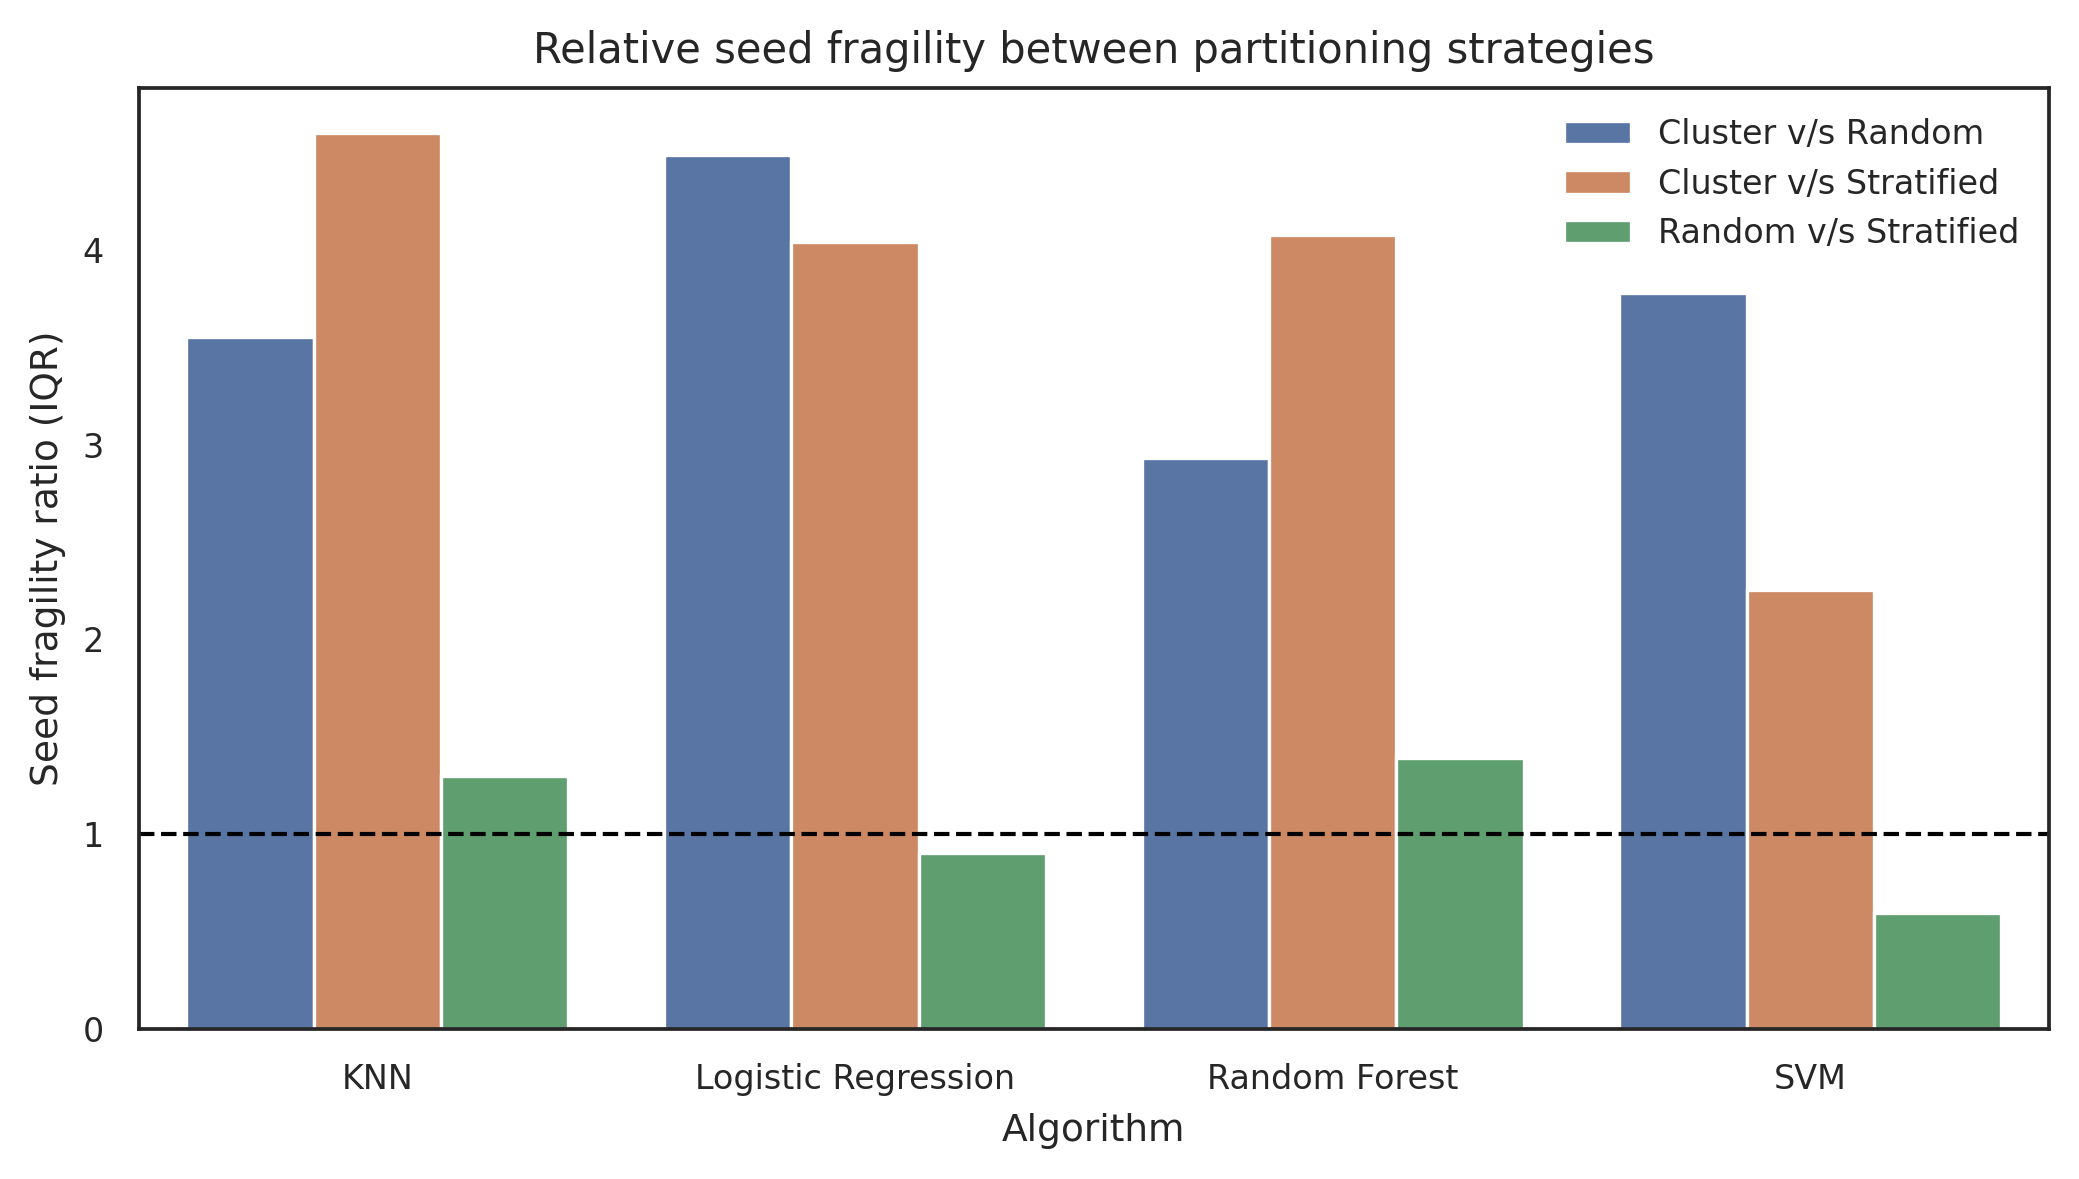

In [19]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=ratio_long,
    x="Algorithm",
    y="Fragility ratio",
    hue="Comparison",
    errorbar=None
)

plt.axhline(1.0, linestyle="--", color="black", linewidth=1)
plt.ylabel("Seed fragility ratio (IQR)")
plt.xlabel("Algorithm")
plt.title("Relative seed fragility between partitioning strategies")
plt.legend(frameon=False)

plt.tight_layout()
plt.show()


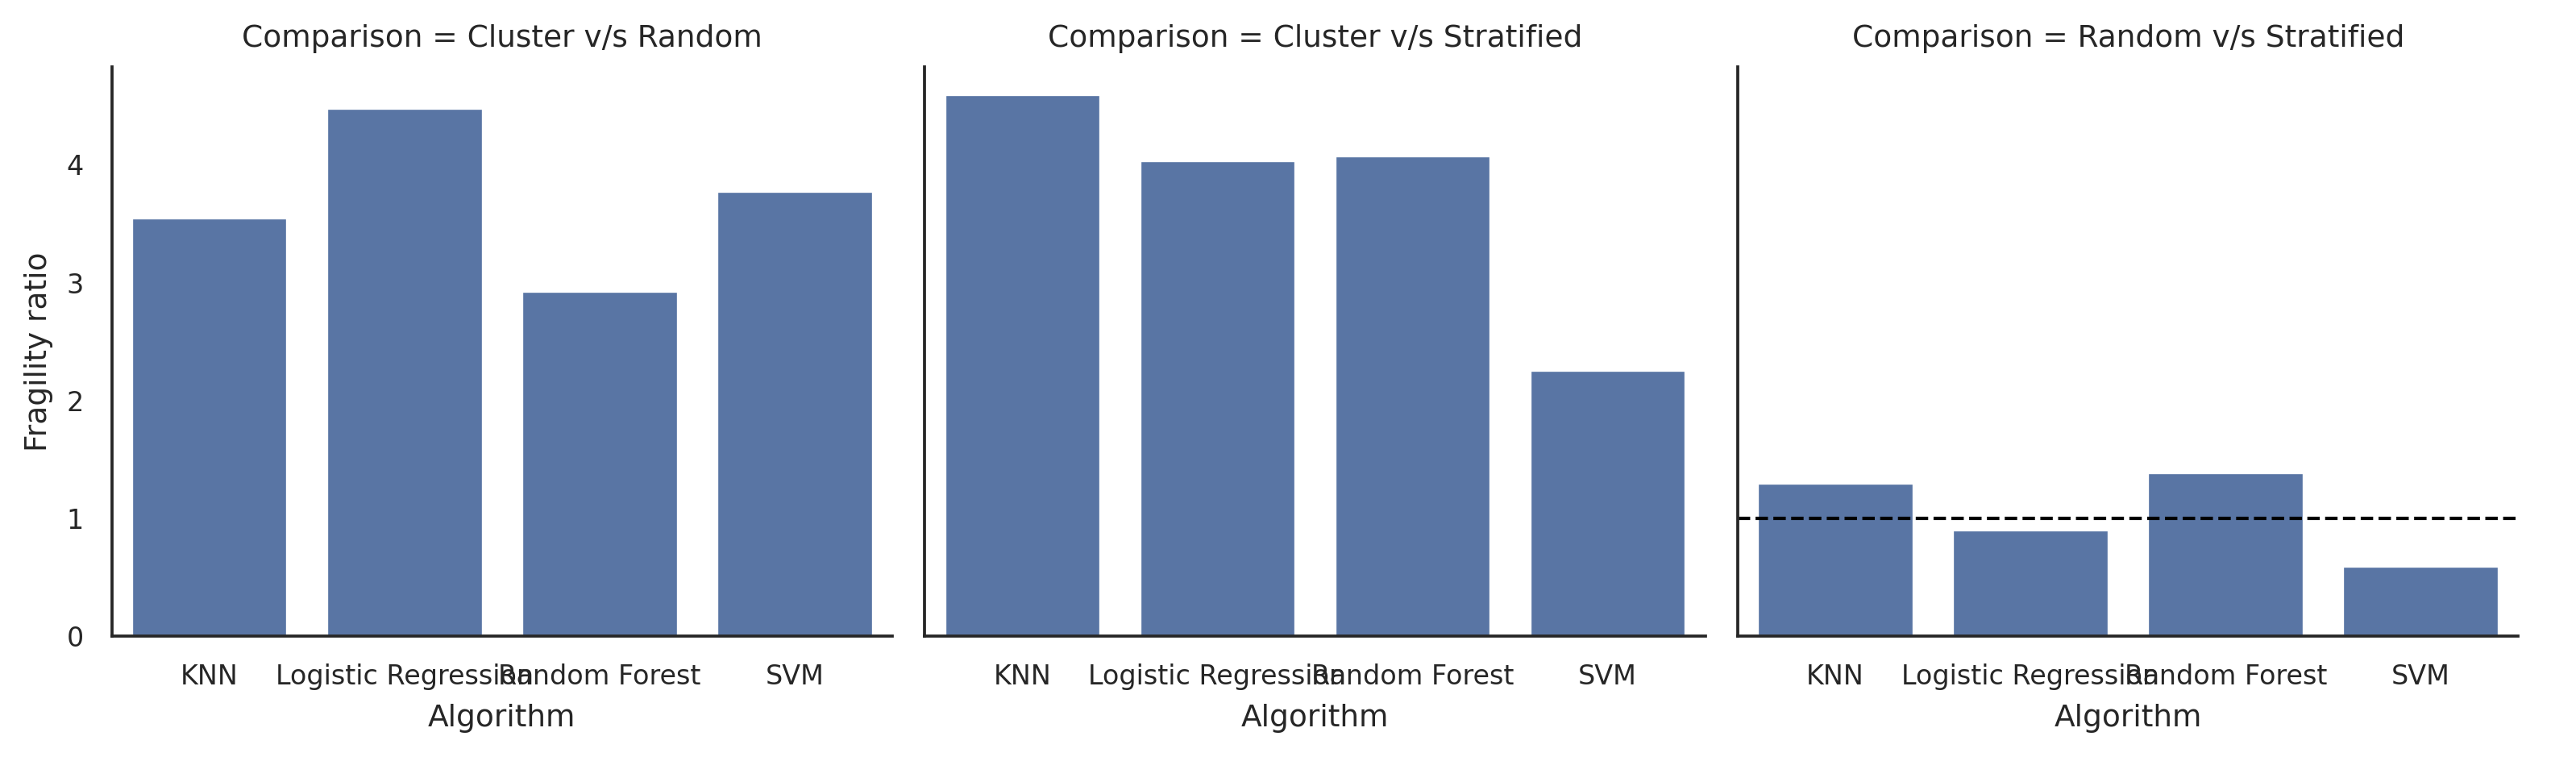

In [20]:
sns.catplot(
    data=ratio_long,
    x="Algorithm",
    y="Fragility ratio",
    col="Comparison",
    kind="bar",
    height=3.2,
    aspect=1.1,
    sharey=True,
    errorbar=None
)

plt.axhline(1.0, linestyle="--", color="black", linewidth=1)
plt.show()


In [21]:
df_performances["Gap"] = df_performances["AUPRC test"] - df_performances["AUPRC val"]


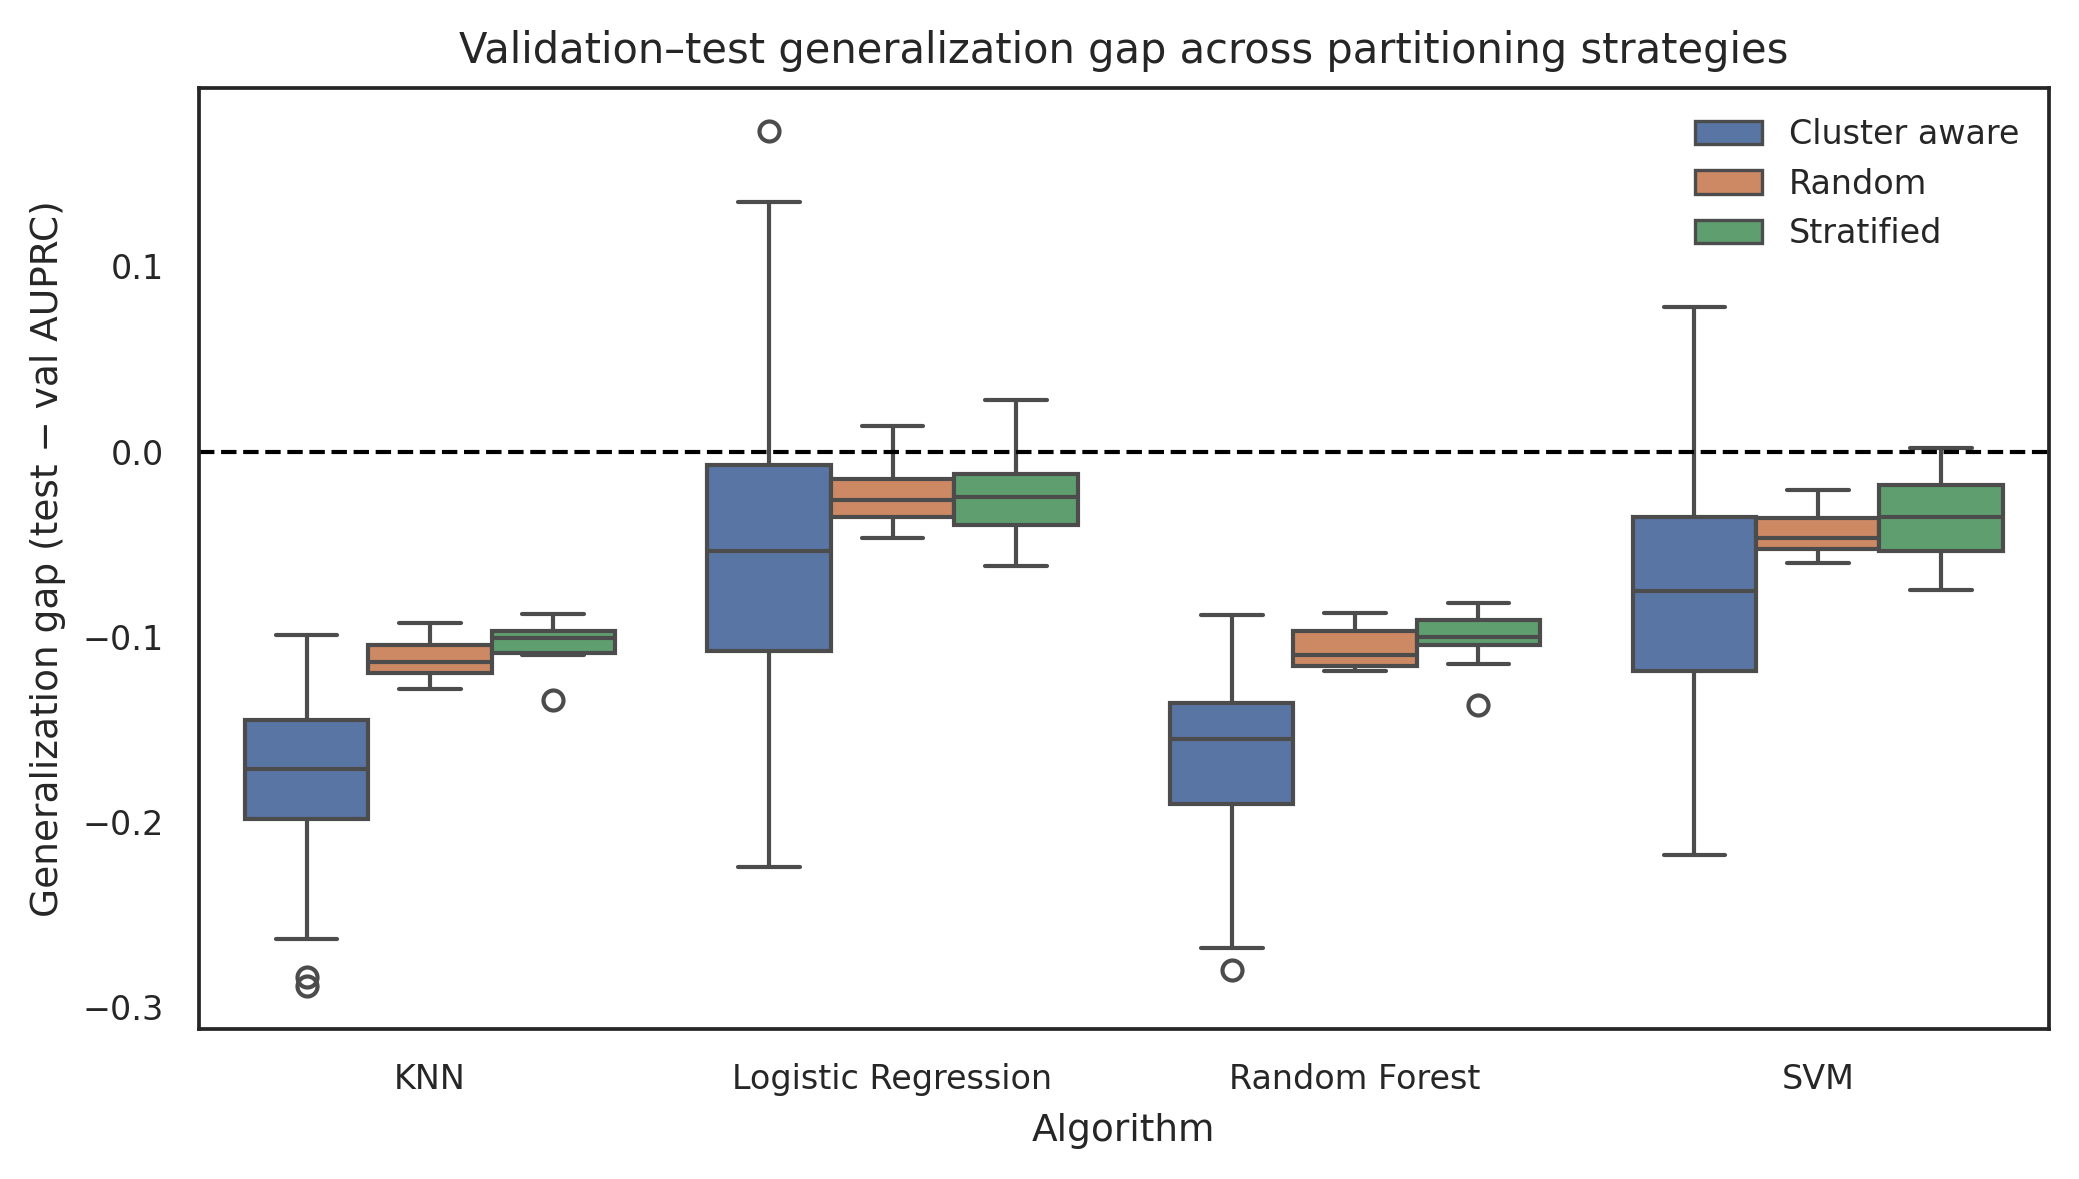

In [22]:

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_performances,
    x="Algorithm",
    y="Gap",
    hue="Partition",
    showfliers=True
)

plt.axhline(0, linestyle="--", color="black", linewidth=1)
plt.ylabel("Generalization gap (test − val AUPRC)")
plt.xlabel("Algorithm")
plt.title("Validation–test generalization gap across partitioning strategies")
plt.legend(frameon=False)

plt.tight_layout()
plt.show()


In [23]:
gap_summary = (
    df_performances
    .groupby(["Algorithm", "Partition"])["Gap"]
    .agg(
        median_gap="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

gap_summary


,Algorithm,Partition,median_gap,q25,q75
0,KNN,Cluster aware,-0.171286,-0.198562,-0.144661
1,KNN,Random,-0.113699,-0.119461,-0.104283
2,KNN,Stratified,-0.100645,-0.108653,-0.096939
3,Logistic Regression,Cluster aware,-0.053587,-0.107458,-0.007380
4,Logistic Regression,Random,-0.026091,-0.035431,-0.014875
5,Logistic Regression,Stratified,-0.024589,-0.039853,-0.012163
6,Random Forest,Cluster aware,-0.155364,-0.190219,-0.135749
7,Random Forest,Random,-0.109607,-0.115679,-0.097095
8,Random Forest,Stratified,-0.100061,-0.104402,-0.091042
9,SVM,Cluster aware,-0.075369,-0.118277,-0.035269


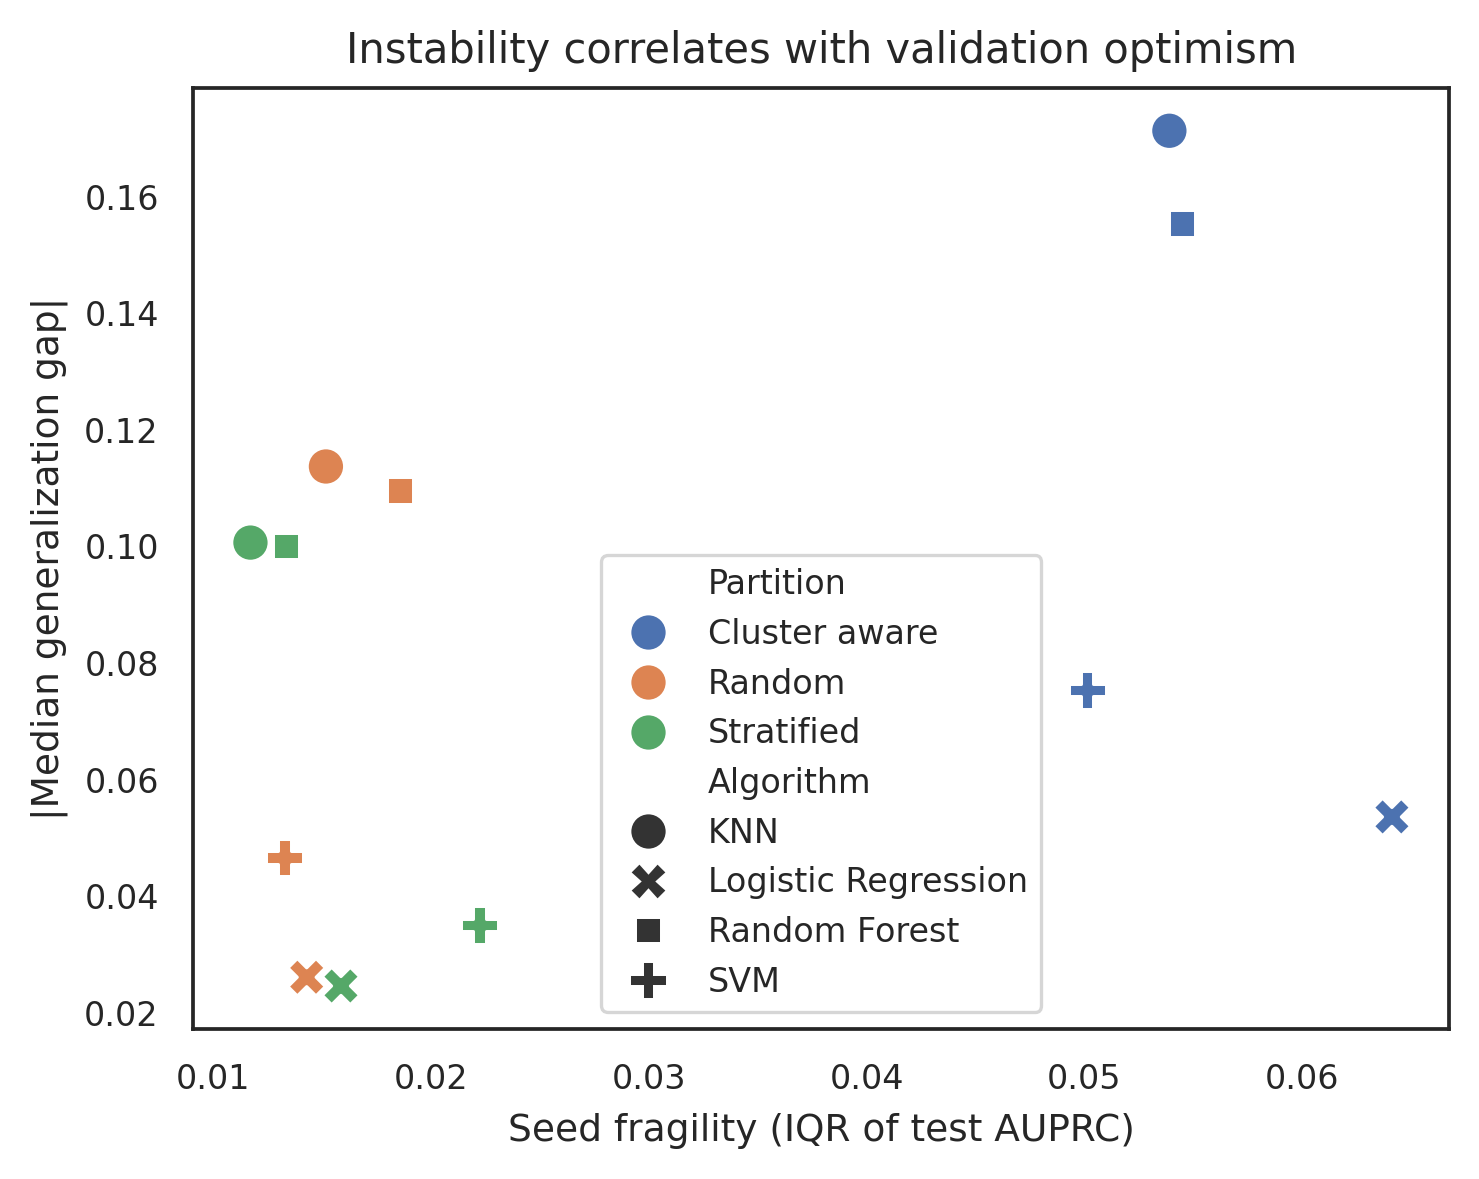

In [24]:
merged = fragility.merge(
    gap_summary[["Algorithm", "Partition", "median_gap"]],
    on=["Algorithm", "Partition"]
)

merged["abs_gap"] = merged["median_gap"].abs()

plt.figure(figsize=(5, 4))
sns.scatterplot(
    data=merged,
    x="IQR",
    y="abs_gap",
    hue="Partition",
    style="Algorithm",
    s=80
)

plt.xlabel("Seed fragility (IQR of test AUPRC)")
plt.ylabel("|Median generalization gap|")
plt.title("Instability correlates with validation optimism")
plt.tight_layout()
plt.show()


In [25]:
df_k = df_performances[df_performances["Partition"] == "Cluster aware"].copy()


In [26]:
perf_k = (
    df_k
    .groupby(["Algorithm", "k"])["AUPRC test"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    )
    .reset_index()
)


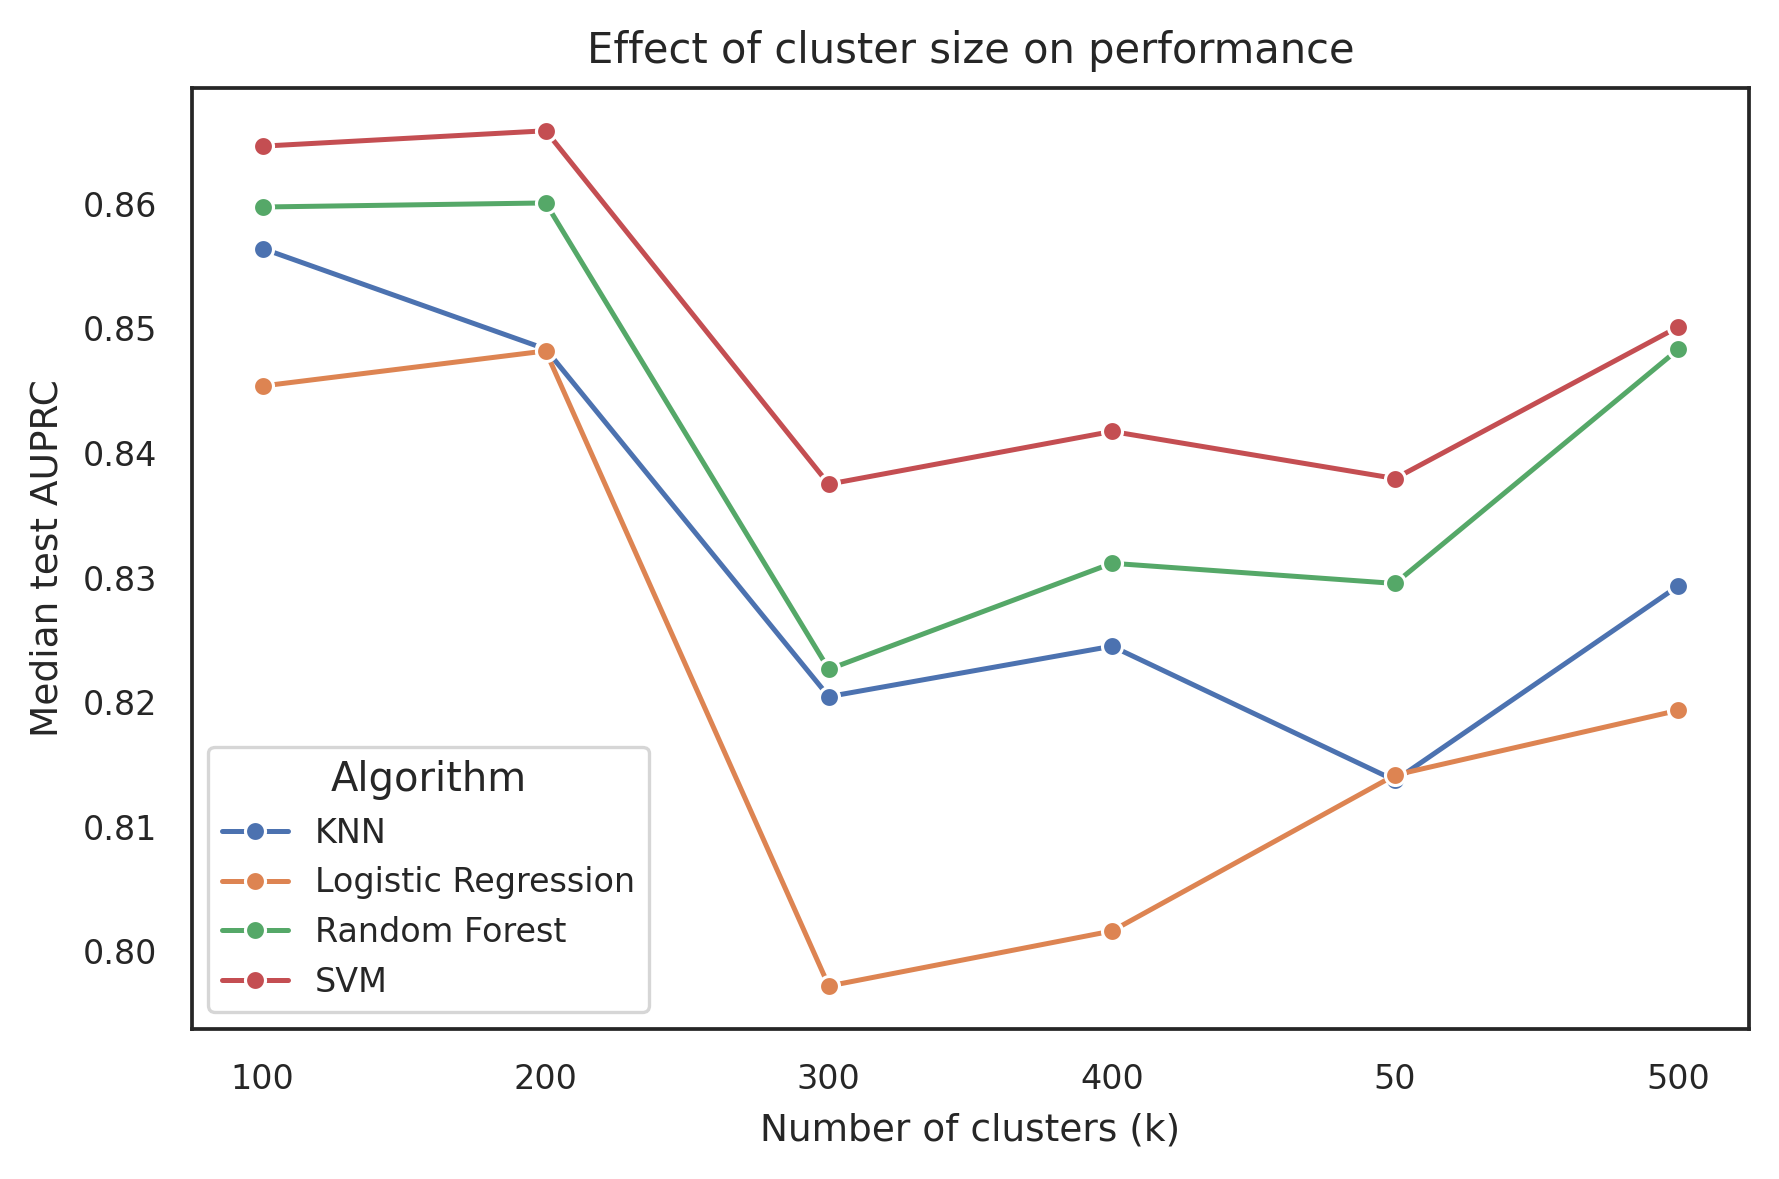

In [27]:
plt.figure(figsize=(6,4))
sns.lineplot(
    data=perf_k,
    x="k",
    y="median",
    hue="Algorithm",
    marker="o"
)

plt.ylabel("Median test AUPRC")
plt.xlabel("Number of clusters (k)")
plt.title("Effect of cluster size on performance")
plt.tight_layout()
plt.show()


In [28]:
frag_k = (
    df_k
    .groupby(["Algorithm", "k"])["AUPRC test"]
    .agg(
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

frag_k["IQR"] = frag_k["q75"] - frag_k["q25"]


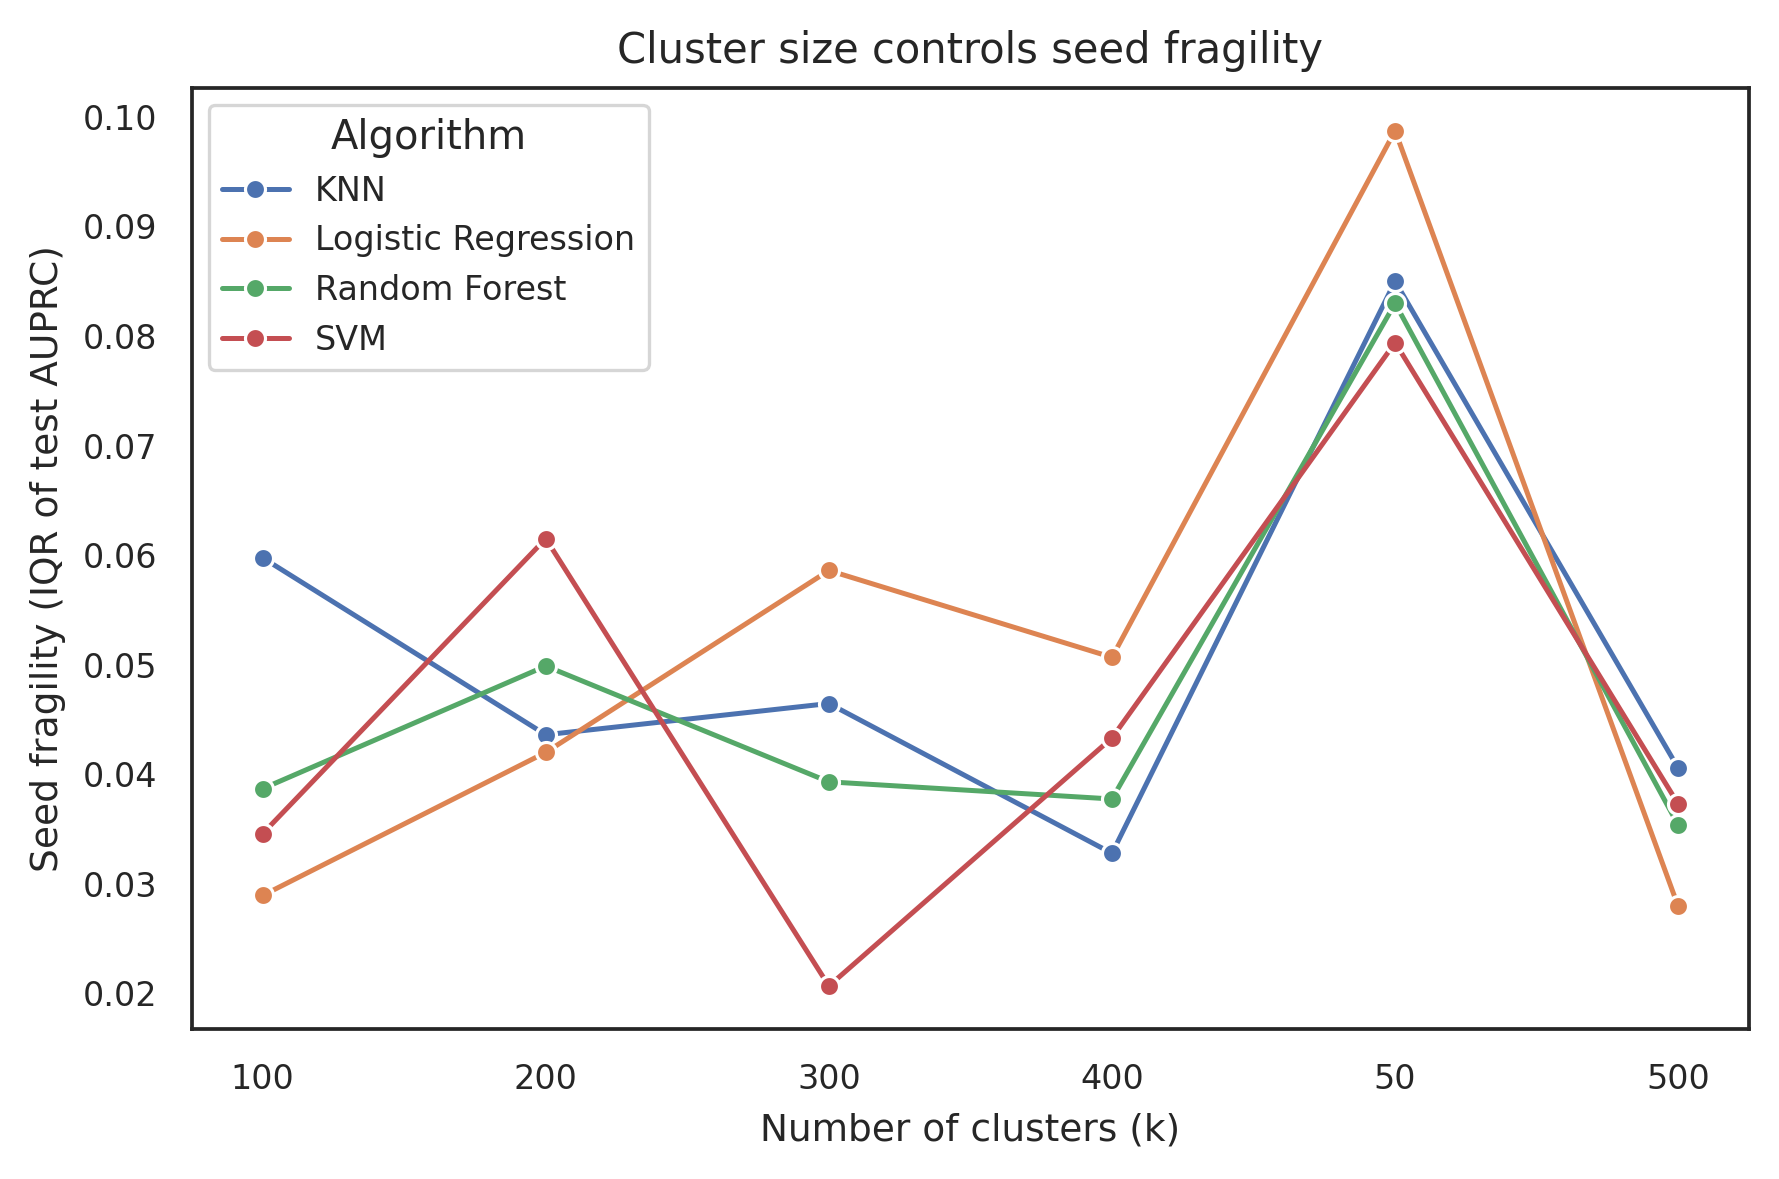

In [29]:
plt.figure(figsize=(6,4))
sns.lineplot(
    data=frag_k,
    x="k",
    y="IQR",
    hue="Algorithm",
    marker="o"
)

plt.ylabel("Seed fragility (IQR of test AUPRC)")
plt.xlabel("Number of clusters (k)")
plt.title("Cluster size controls seed fragility")
plt.tight_layout()
plt.show()


In [30]:
gap_k = (
    df_k
    .groupby(["Algorithm", "k"])["Gap"]
    .agg(
        median_gap="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    )
    .reset_index()
)


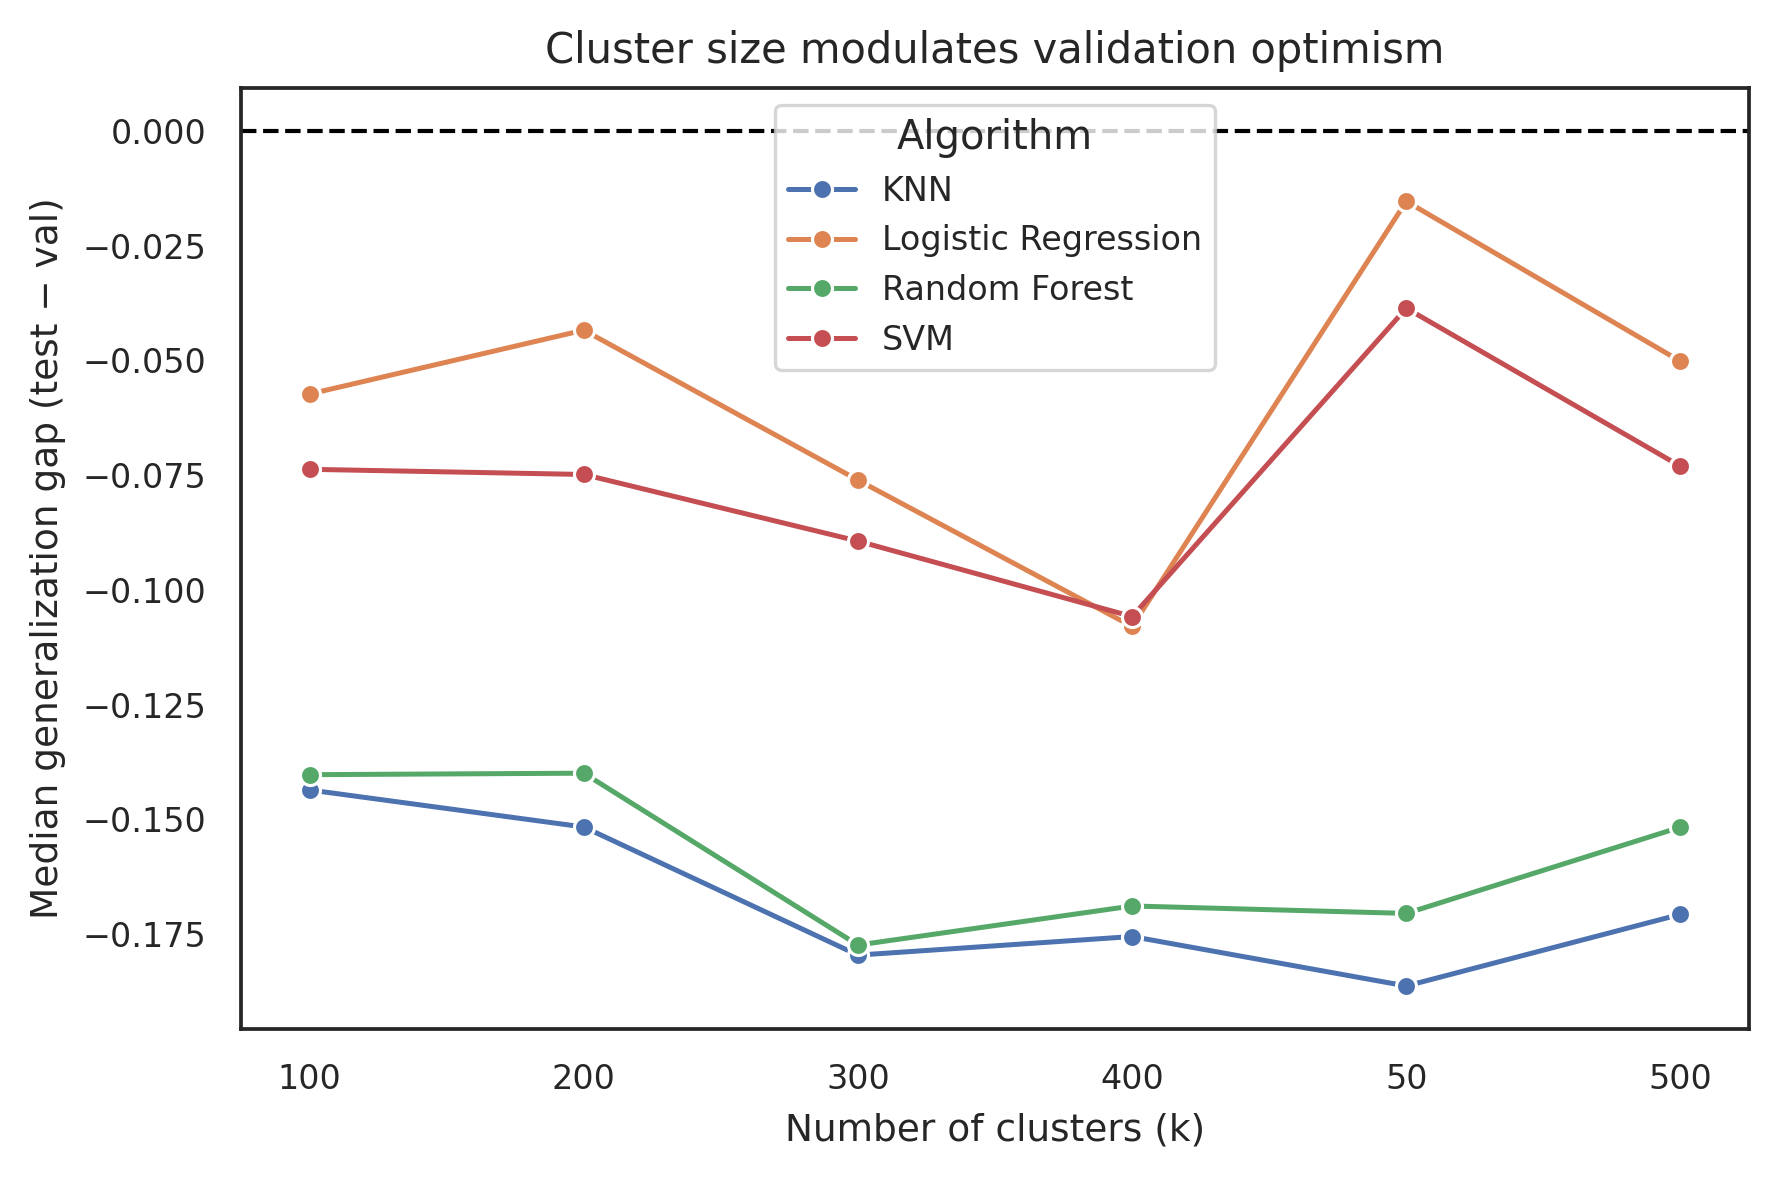

In [31]:
plt.figure(figsize=(6,4))
sns.lineplot(
    data=gap_k,
    x="k",
    y="median_gap",
    hue="Algorithm",
    marker="o"
)

plt.axhline(0, linestyle="--", color="black", linewidth=1)
plt.ylabel("Median generalization gap (test − val)")
plt.xlabel("Number of clusters (k)")
plt.title("Cluster size modulates validation optimism")
plt.tight_layout()
plt.show()


In [45]:
PARTITION_COLORS = {
    "Cluster aware": "#005f73",   
    "Random": "#0a9396",          
    "Stratified": "#94d2bd"       
}

In [46]:
ALGO_COLORS = {
    "KNN": "#62b6cb",
    "Logistic Regression": "#1b4965",
    "Random Forest": "#5fa8d3",
    "SVM": "#bee9e8"
}

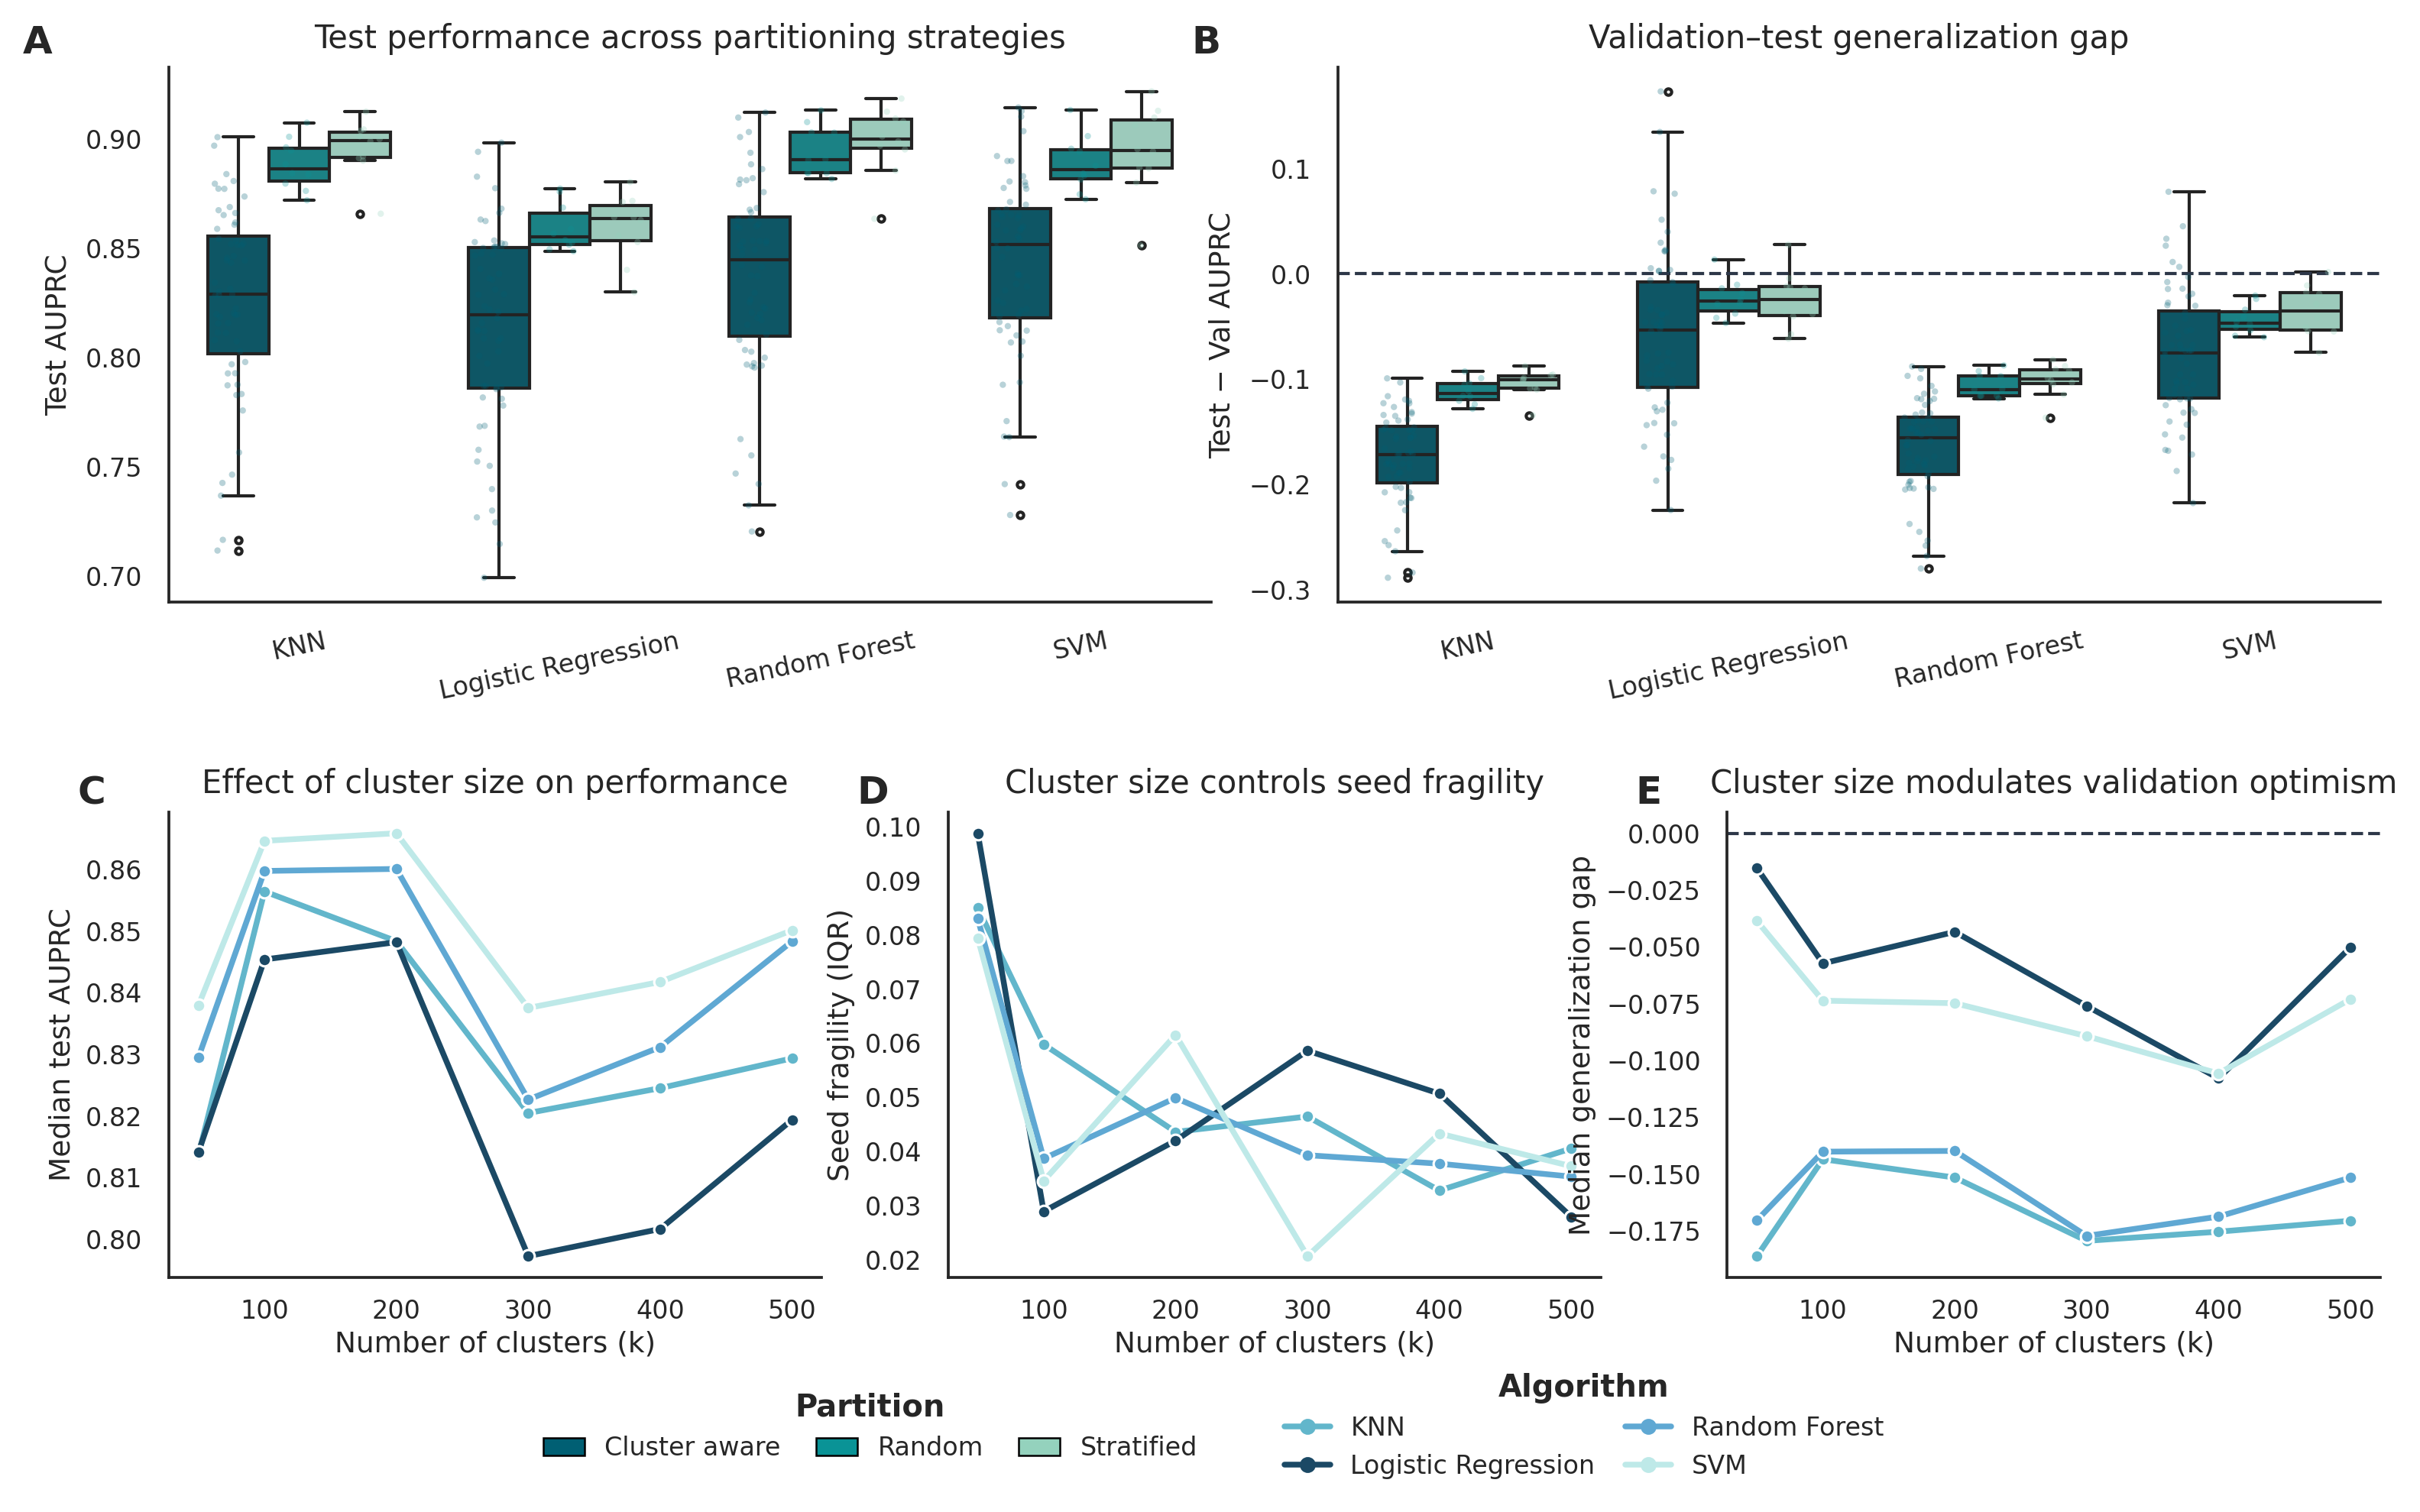

In [48]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

ALGO_ORDER = ["KNN", "Logistic Regression", "Random Forest", "SVM"]
PART_ORDER = ["Cluster aware", "Random", "Stratified"]

# -------------------------
# Style (Nature-ish)
# -------------------------
sns.set_theme(style="white", context="paper")
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.9,
})

# -------------------------
# Defensive casting + ordering
# -------------------------
df_performances["Algorithm"] = pd.Categorical(df_performances["Algorithm"], categories=ALGO_ORDER, ordered=True)
df_performances["Partition"] = pd.Categorical(df_performances["Partition"], categories=PART_ORDER, ordered=True)
df_performances = df_performances.sort_values(["Algorithm", "Partition"])

perf_k = perf_k.copy()
frag_k = frag_k.copy()
gap_k  = gap_k.copy()

for _df in [perf_k, frag_k, gap_k]:
    if "Algorithm" in _df.columns:
        _df["Algorithm"] = pd.Categorical(_df["Algorithm"], categories=ALGO_ORDER, ordered=True)
    if "k" in _df.columns:
        _df["k"] = pd.to_numeric(_df["k"], errors="coerce").astype(int)

# enforce consistent k order (avoids weird ordering)
k_order = sorted(pd.unique(pd.concat([perf_k["k"], frag_k["k"], gap_k["k"]], ignore_index=True)))

# Keep seaborn behavior stable: categorical k with explicit order
for _df in [perf_k, frag_k, gap_k]:
    _df["k"] = pd.Categorical(_df["k"], categories=k_order, ordered=True)
    _df.sort_values(["Algorithm", "k"], inplace=True)

# -------------------------
# Figure layout (2 rows)
# Top row: A (0:3), B (3:6)
# Bottom row: C (0:2), D (2:4), E (4:6)
# -------------------------
fig = plt.figure(figsize=(10.6, 6.6))
gs = GridSpec(
    nrows=2, ncols=6,
    height_ratios=[1.15, 1.0],
    hspace=0.42,   # tuned (brings C/D/E up)
    wspace=0.48    # tuned (more space between A and B)
)

axA = fig.add_subplot(gs[0, 0:3])
axB = fig.add_subplot(gs[0, 3:6])
axC = fig.add_subplot(gs[1, 0:2])
axD = fig.add_subplot(gs[1, 2:4])
axE = fig.add_subplot(gs[1, 4:6])

# -------------------------
# Panel A — Performance (box + jitter)
# -------------------------
sns.boxplot(
    data=df_performances,
    x="Algorithm",
    y="AUPRC test",
    hue="Partition",
    order=ALGO_ORDER,
    hue_order=PART_ORDER,
    palette=PARTITION_COLORS,   # <- your colors
    ax=axA,
    width=0.70,
    fliersize=2,
    linewidth=1.0
)
sns.stripplot(
    data=df_performances,
    x="Algorithm",
    y="AUPRC test",
    hue="Partition",
    order=ALGO_ORDER,
    hue_order=PART_ORDER,
    palette=PARTITION_COLORS,   # <- your colors
    ax=axA,
    dodge=True,
    jitter=0.18,
    size=2.0,
    alpha=0.28,
    linewidth=0
)

axA.set_title("Test performance across partitioning strategies")
axA.set_ylabel("Test AUPRC")
axA.set_xlabel("")
axA.tick_params(axis="x", rotation=12)
if axA.get_legend() is not None:
    axA.get_legend().remove()

# -------------------------
# Panel B — Generalization gap (box + jitter)
# -------------------------
sns.boxplot(
    data=df_performances,
    x="Algorithm",
    y="Gap",
    hue="Partition",
    order=ALGO_ORDER,
    hue_order=PART_ORDER,
    palette=PARTITION_COLORS,   # <- your colors
    ax=axB,
    width=0.70,
    fliersize=2,
    linewidth=1.0
)
sns.stripplot(
    data=df_performances,
    x="Algorithm",
    y="Gap",
    hue="Partition",
    order=ALGO_ORDER,
    hue_order=PART_ORDER,
    palette=PARTITION_COLORS,   # <- your colors
    ax=axB,
    dodge=True,
    jitter=0.18,
    size=2.0,
    alpha=0.28,
    linewidth=0
)

axB.axhline(0, ls="--", lw=1.0, c="#2D3748")
axB.set_title("Validation–test generalization gap")
axB.set_ylabel("Test − Val AUPRC")
axB.set_xlabel("")
axB.tick_params(axis="x", rotation=12)
if axB.get_legend() is not None:
    axB.get_legend().remove()

# -------------------------
# Panel C — k vs performance
# -------------------------
sns.lineplot(
    data=perf_k,
    x="k", y="median",
    hue="Algorithm",
    hue_order=ALGO_ORDER,
    palette=ALGO_COLORS,        # <- your colors
    marker="o",
    markersize=4,
    linewidth=1.8,
    ax=axC
)
axC.set_title("Effect of cluster size on performance")
axC.set_ylabel("Median test AUPRC")
axC.set_xlabel("Number of clusters (k)")
if axC.get_legend() is not None:
    axC.get_legend().remove()

# -------------------------
# Panel D — k vs fragility
# -------------------------
sns.lineplot(
    data=frag_k,
    x="k", y="IQR",
    hue="Algorithm",
    hue_order=ALGO_ORDER,
    palette=ALGO_COLORS,        # <- your colors
    marker="o",
    markersize=4,
    linewidth=1.8,
    ax=axD
)
axD.set_title("Cluster size controls seed fragility")
axD.set_ylabel("Seed fragility (IQR)")
axD.set_xlabel("Number of clusters (k)")
if axD.get_legend() is not None:
    axD.get_legend().remove()

# -------------------------
# Panel E — k vs optimism (gap)
# -------------------------
sns.lineplot(
    data=gap_k,
    x="k", y="median_gap",
    hue="Algorithm",
    hue_order=ALGO_ORDER,
    palette=ALGO_COLORS,        # <- your colors
    marker="o",
    markersize=4,
    linewidth=1.8,
    ax=axE
)
axE.axhline(0, ls="--", lw=1.0, c="#2D3748")
axE.set_title("Cluster size modulates validation optimism")
axE.set_ylabel("Median generalization gap")
axE.set_xlabel("Number of clusters (k)")
if axE.get_legend() is not None:
    axE.get_legend().remove()

# -------------------------
# Fix x tick overlap in C/D/E (no manual ticks; just pad)
# -------------------------
for ax in [axC, axD, axE]:
    ax.tick_params(axis="x", rotation=0, pad=2)
    ax.xaxis.labelpad = 2
    ax.yaxis.labelpad = 3
    for t in ax.get_xticklabels():
        t.set_horizontalalignment("center")

# -------------------------
# Panel labels
# -------------------------
for label, ax in zip(["A", "B", "C", "D", "E"], [axA, axB, axC, axD, axE]):
    ax.text(
        -0.14, 1.08, label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        ha="left"
    )

# -------------------------
# Legend handles (manual)
# -------------------------
partition_handles = [
    Patch(facecolor=PARTITION_COLORS[k], edgecolor="black", linewidth=0.6, label=k)
    for k in PART_ORDER
]
algo_handles = [
    Line2D([0], [0], color=ALGO_COLORS[k], marker="o", lw=1.8, markersize=4, label=k)
    for k in ALGO_ORDER
]

# -------------------------
# Cosmetics + global spacing
# -------------------------
sns.despine(fig=fig)

# Bring figure content up, keep small legend zone inside bottom margin (no huge whitespace)
fig.subplots_adjust(
    top=0.94,
    bottom=0.14,  # enough for legends inside canvas
    left=0.07,
    right=0.98,
    hspace=0.42,
    wspace=0.48
)

# Remove any existing global legends (avoid duplicates)
for lg in fig.legends:
    lg.remove()

# -------------------------
# Bottom legends (same format as your screenshot, but at bottom)
# -------------------------
LEGEND_Y = 0.012

# tighter horizontal spacing (bring both legends toward center)
X_LEFT  = 0.22   # Partition block moves right
X_RIGHT = 0.78   # Algorithm block moves left

leg_part = fig.legend(
    handles=partition_handles,
    labels=[h.get_label() for h in partition_handles],
    loc="lower left",
    bbox_to_anchor=(X_LEFT, LEGEND_Y),
    ncol=3,
    frameon=False,
    title="Partition",
    handlelength=1.6,
    columnspacing=1.4,
    borderaxespad=0.0
)
leg_part.get_title().set_fontweight("bold")

leg_algo = fig.legend(
    handles=algo_handles,
    labels=[h.get_label() for h in algo_handles],
    loc="lower right",
    bbox_to_anchor=(X_RIGHT, 0),
    ncol=2,
    frameon=False,
    title="Algorithm",
    handlelength=1.8,
    columnspacing=1.2,
    borderaxespad=0.0
)
leg_algo.get_title().set_fontweight("bold")


# Optional save (recommended with tight bbox)
fig.savefig("mcs_case_study_amp_figure.png", bbox_inches="tight")
fig.savefig("mcs_case_study_amp_figure.pdf", bbox_inches="tight")

plt.show()
